In [67]:
import numpy as np
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import os
import PcmPy as pcm
from Pcm import find_model
import globals as gl
from Plot import add_colorbar, set_spines_and_ticks_width, set_dark_background

from util import r_squared
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.style.use('default')

%config InlineBackend.figure_format = 'svg'

0 - model fit SLR: 0.27912186948201334
1 - model fit LLR: 0.6546539958381863
2 - model fit Vol: 0.9272265938361473


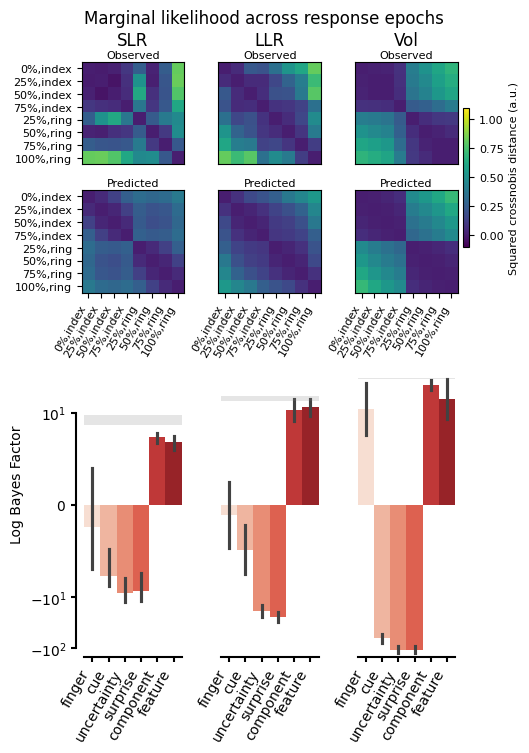

In [68]:
epochs = ['SLR', 'LLR', 'Vol']
experiment = 'smp0'

Mf, idxf = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.emg.pkl'), 'feature')

fig, axs = plt.subplots(1, len(epochs), figsize=(5, 4.5), sharey=True,)

vmin, vmax = -.1, 1.1

for r, epoch in enumerate(epochs):

    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.emg.{epoch}.pkl'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.emg.{epoch}.pkl'))

    plt.sca(axs[r])
    ax = pcm.model_plot(T_cv.likelihood,
                    null_model = 'null',
                    noise_ceiling= 'ceil',
                    upper_ceiling = T_gr.likelihood['ceil'],
                    width=1,
                    palette='Reds',
                    errorbar='se')
    ax.set_xlabel('')
    ax.set_yscale('symlog')
    ax.set_ylim((-150, 10**3))
    ax.spines[['left',]].set_bounds(-10**2, 10)
    ax.set_yticks([-10**2, -10, 0, 10, ])
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')
    ax.tick_params(axis='y', which='minor', left=False)

    ax.set_xlim(-1, 6)
    ax.spines[['bottom',]].set_bounds(-.5, 5.5)

    ax.set_title(f'{epoch}', pad=12)

    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.emg.{epoch}.npy'))
    D_obs = pcm.G_to_dist(G_obs.mean(axis=0) / np.trace(G_obs.mean(axis=0)))

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_cv.emg.{epoch}.pkl'), "rb")
    theta = pickle.load(f)
    theta_f = theta[idxf][:Mf.n_param]

    Df = []
    for i in range(theta_f.shape[1]):
        G_hat_f, _ = Mf.predict(theta_f[:, i])
        Df.append(pcm.G_to_dist(G_hat_f / np.trace(G_hat_f)))

    G_hat = []
    for i in range(theta_f.shape[1]):
        G_hat_tmp, _ = Mf.predict(theta_f[:, i])
        G_hat.append(G_hat_tmp)

    G_hat = np.array(G_hat)

    correlations = []
    for i in range(G_hat.shape[0]):
        # Average G_hat across all folds except i
        G_hat_mean = np.mean(np.delete(G_hat, i, axis=0), axis=0)

        G_hat_mean /= np.trace(G_hat_mean)
        G_obs[i] /= np.trace(G_obs[i])

        # Vectorize upper triangle (excluding diagonal)
        mask = np.triu_indices_from(G_obs[i], k=1)
        vec_obs = G_obs[i][mask]
        vec_hat = G_hat_mean[mask]

        # Compute correlation using np.corrcoef
        corr = np.corrcoef(vec_obs, vec_hat)[0, 1]
        correlations.append(corr)

    correlations = np.array(correlations).mean()

    print(f"{r} - model fit {epoch}: {correlations}")

    insetx = .05
    insety = (1.05, 1.42)
    insetw = .9
    inseth = .3
    cbarc = (insety[0] + insety[1] + inseth) / 2
    cbarx = 1
    cbarw = 0.4

    # Create first inset (upper)
    inset1 = ax.inset_axes([insetx, insety[1], insetw, inseth], transform=ax.transAxes)  # [x0, y0, width, height]
    cax = inset1.imshow(D_obs, vmin=vmin, vmax=vmax)  # Replace with your plotting code for the first inset
    inset1.set_xticks([])
    inset1.set_yticks([])
    inset1.set_title('Observed', fontsize=8, pad=3)
    if r==0:
        inset1.set_yticks(np.arange(8))
        inset1.set_yticklabels(list(gl.regressor_mapping.keys())[5:13], fontsize=8)

    # Create second inset (just below the first)
    inset2 = ax.inset_axes([insetx, insety[0], insetw, inseth], transform=ax.transAxes)
    inset2.imshow(np.array(Df).mean(axis=0), vmin=vmin, vmax=vmax)
    inset2.set_title('Predicted', fontsize=8, pad=3)
    inset2.set_xticks(np.arange(8))
    inset2.set_xticklabels(list(gl.regressor_mapping.keys())[5:13], fontsize=8, rotation=60, ha='right')
    inset2.set_yticks([])
    if r==0:
        inset2.set_yticks(np.arange(8))
        inset2.set_yticklabels(list(gl.regressor_mapping.keys())[5:13], fontsize=8,)

    # Add colorbar
    if r == len(epochs) - 1:
        cbar_ax = ax.inset_axes([cbarx, cbarc-cbarw/2, 0.05, cbarw], transform=ax.transAxes)  # [left, bottom, width, height] in figure coordinates
        cbar = fig.colorbar(cax, cax=cbar_ax)
        cbar.ax.tick_params(labelsize=8)
        cbar.set_label('Squared crossnobis distance (a.u.)', fontsize=8)

    if r == 0:
        ax.spines[['top', 'right',]].set_visible(False)
        set_spines_and_ticks_width(ax, spine_width=1.5,spine_sides=('left', 'bottom',), tick_width=1.5,axes=('x', 'y'),which='both')

    else:
        ax.spines[['top', 'right','left']].set_visible(False)
        set_spines_and_ticks_width(ax, tick_width=0, axes='y')
        set_spines_and_ticks_width(ax, spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes='x',which='both')

fig.suptitle('Marginal likelihood across response epochs',y=1.55)
# set_dark_background(fig)

# save_figure_incremental(fig, 'ml_emg')

plt.show()

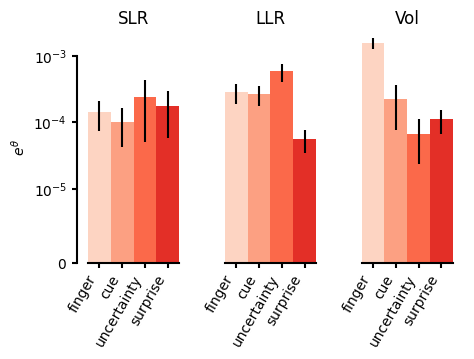

In [69]:
epochs = ['SLR', 'LLR', 'Vol']
experiment = 'smp0'

components = ['finger', 'cue', 'uncertainty', 'surprise']

M, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.emg.pkl'), 'component')

n_param = M.n_param

fig, axs = plt.subplots(1, len(epochs),sharey=True, figsize=(5, 3), )

colors = sns.color_palette("Reds", n_colors=5)[:4]

for r, epoch in enumerate(epochs):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.emg.{epoch}.pkl'), "rb")
    theta = np.exp(pickle.load(f)[idx][:n_param])

    theta_avg = theta.mean(axis=1)
    theta_err = theta.std(axis=1) / np.sqrt(theta.shape[1])

    axs[r].bar(components, theta_avg, width=1, facecolor=colors, yerr=theta_err,)
    axs[r].set_xticks(axs[r].get_xticks())
    axs[r].set_xticklabels(axs[r].get_xticklabels(), rotation=60, ha='right')
    axs[r].set_yscale('symlog', linthresh=1e-5)
    axs[r].set_title(f'{epoch}')
    axs[r].spines[['bottom',]].set_bounds(-.5, 3.5)
    axs[r].set_xlim(-1, 4)

    if r == 0:
        axs[r].set_ylabel(r'$e^{\theta}$')
        axs[r].spines[['top', 'right',]].set_visible(False)
        axs[r].spines[['left',]].set_bounds(0, 10**-3)
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('left', 'bottom',), tick_width=1.5,axes=('x', 'y'),which='both')
    else:
        axs[r].spines[['top', 'right','left']].set_visible(False)
        set_spines_and_ticks_width(axs[r], tick_width=0, axes='y')
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes='x',which='both')

# save_figure_incremental(fig, 'comp_model_coeff_emg')

plt.show()

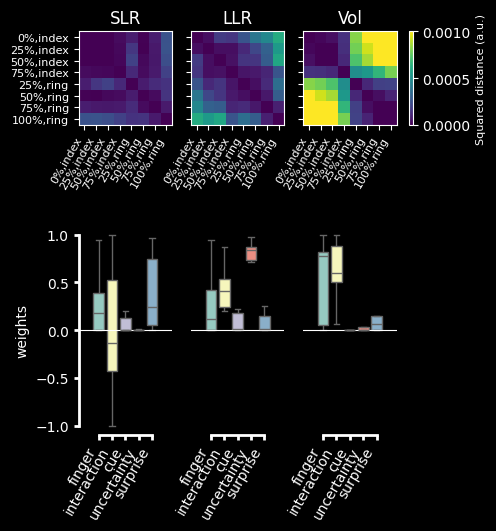

In [121]:
#epochs = ['SLR', 'LLR', 'Vol']
experiment = 'smp0'
plt.style.use('dark_background')

features = np.array(['finger', 'interaction','cue', 'uncertainty', 'surprise'])

Mf, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.emg.pkl'), 'feature')

Ac = Mf.Ac.sum(axis=0)
n_param = Mf.n_param

vmin, vmax = -0, .001

colors = sns.color_palette("Set3", n_colors=5) #+ [(.5, .5, .5)]
#colors = np.array(colors)[np.array([0, 4, 1, 2, 3])]

fig, axs = plt.subplots(2, len(epochs), figsize=(4, 6), sharey='row')

for r, epoch in enumerate(epochs):

    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.emg.{epoch}.npy')).mean(axis=0)
    D_obs = pcm.G_to_dist(G_obs)
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.emg.{epoch}.pkl'), "rb")

    # Top row: imshow
    im_ax = axs[0, r]
    cax = im_ax.imshow(D_obs, vmin=vmin, vmax=vmax)
    im_ax.set_xticks(np.arange(8))
    im_ax.set_xticklabels(list(gl.regressor_mapping.keys())[5:13], fontsize=8, rotation=60, ha='right')
    im_ax.set_title(epoch)
    if r==0:
        im_ax.set_yticks(np.arange(8))
        im_ax.set_yticklabels(list(gl.regressor_mapping.keys())[5:13], fontsize=8)

    # # Middle row: MDS
    # scatter_ax = axs[1, r]
    # W, _ = pcm.classical_mds(G_obs/ np.trace(G_obs))
    # scatter_ax.scatter(W[:, 1], W[:, 0], c=list(gl.colour_mapping.values())[5:13])
    # scatter_ax.set_xlim(-.8, .8)
    # scatter_ax.set_ylim(scatter_ax.get_xlim())
    # scatter_ax.set_xticks([-.5, .5])
    # scatter_ax.set_yticks([-.5, .5])
    # scatter_ax.set_aspect('equal')
    # scatter_ax.spines[['top', 'right']].set_visible(False)
    # scatter_ax.spines[['bottom', 'left']].set_bounds(-.5, .5)
    # if r>0:
    #     scatter_ax.spines[['top', 'right', 'left']].set_visible(False)

    # Bottom row: bar plot
    row_ax = axs[1, r]
    params = pickle.load(f)[idx]
    theta = params[:n_param]
    theta2 = theta**2
    theta_combined = np.vstack([theta2[0, :], theta[1, :], theta2[3, :],theta2[4:]])
    theta_scaled = theta_combined / np.linalg.norm(theta_combined, axis=0, keepdims=True)
    theta_avg = theta_scaled.mean(axis=1)
    theta_err = theta_scaled.std(axis=1) / np.sqrt(theta_scaled.shape[1])

    df = pd.DataFrame(theta_scaled.T, columns=features)

    # row_ax.bar(features, theta_avg, width=1, yerr=theta_err, color=colors)
    sns.boxplot(data=df, ax=row_ax, palette=colors, showfliers=False)
    row_ax.set_xticks(row_ax.get_xticks())
    row_ax.set_xticklabels(features, rotation=60, ha='right')
    row_ax.axhline(0, color='w', lw=0.8)
    row_ax.set_xlim((-1.5, 5.5))
    row_ax.spines[['top', 'right']].set_visible(False)
    row_ax.spines[['left',]].set_bounds(-1, 1)
    row_ax.spines[['bottom',]].set_bounds(0, 4)

    if r == 0:
        row_ax.set_ylabel('weights')
        row_ax.spines[['bottom','left']].set_linewidth(2)
        row_ax.tick_params(axis='y', width=2)
        row_ax.tick_params(axis='x', width=2)
    else:
        row_ax.spines[['bottom']].set_linewidth(2)
        row_ax.spines[['top', 'right', 'left']].set_visible(False)
        row_ax.tick_params(axis='y', width=0)
        row_ax.tick_params(axis='x', width=2)

# Colorbar for imshow (top row)
fig.subplots_adjust(right=0.92)
bbox = axs[0, 0].get_position()
cbar_ax = fig.add_axes([0.95, bbox.y0, 0.010, bbox.y1 - bbox.y0])
fig.colorbar(cax, cax=cbar_ax).set_label('Squared distance (a.u.)', fontsize=8)

plt.show()

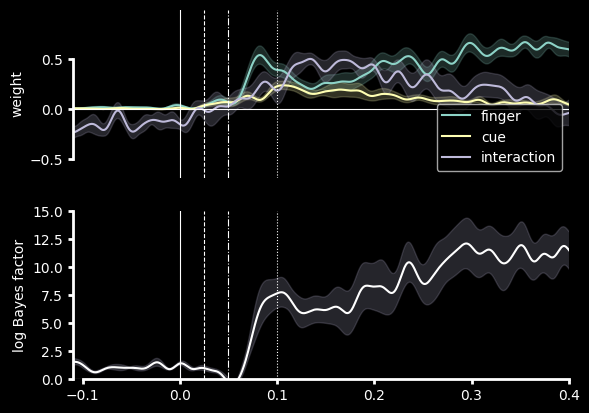

In [104]:
from util import lp_filter
plt.style.use('dark_background')

experiment = 'smp0'

latency = .05

theta = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.emg.continuous.npy'))
T = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.emg.continuous.npy'))[..., 6]

theta2 = theta ** 2
theta_combined = np.array([theta2[..., 0] , theta[...,1] ,  theta2[...,3], theta2[...,4], theta2[...,5]])
theta_scaled = theta_combined / np.linalg.norm(theta_combined, axis=0, keepdims=True)
theta_filtered = lp_filter(theta_scaled, 50, 2148)

N = theta.shape[0]

fig, axs = plt.subplots(2, sharex=True, )

tAx = np.linspace(-1, 2, theta2.shape[1]) - latency

finger = theta_filtered[0]
cue = theta_filtered[2]
interaction = theta_filtered[1]

colors = sns.color_palette("Set3", n_colors=3)

ax = axs[0]

ax.plot(tAx, finger.mean(axis=0), label='finger', color=colors[0])
ax.fill_between(tAx, finger.mean(axis=0) - finger.std(axis=0) / np.sqrt(N),
                 finger.mean(axis=0) + finger.std(axis=0) / np.sqrt(N), color=colors[0], alpha=.2)
ax.plot(tAx, cue.mean(axis=0), label='cue', color=colors[1])
ax.fill_between(tAx, cue.mean(axis=0) - cue.std(axis=0) / np.sqrt(N),
                 cue.mean(axis=0) + cue.std(axis=0) / np.sqrt(N), color=colors[1], alpha=.2)
ax.plot(tAx, interaction.mean(axis=0), label='interaction', color=colors[2])
ax.fill_between(tAx, interaction.mean(axis=0) - interaction.std(axis=0) / np.sqrt(N),
                 interaction.mean(axis=0) + interaction.std(axis=0) / np.sqrt(N), color=colors[2], alpha=.2)

ax.axhline(0, color='w', lw=0.8)
ax.axvline(0, color='w', lw=0.8)
ax.axvline(.025, color='w', lw=0.8, ls='--')
ax.axvline(.05, color='w', lw=0.8, ls='-.')
ax.axvline(.1, color='w', lw=0.8, ls=':')

ax.set_xlim(-.11, .4)

ax.set_ylabel('weight')

ax.spines[['bottom', 'right', 'top']].set_visible(False)
ax.spines[['left',]].set_bounds(-.5, .5)
ax.spines[['left',]].set_linewidth(2)
ax.tick_params(axis='x', which='both', length=0)
ax.tick_params(axis='y', width=2)

ax.legend(loc='lower right')

ax = axs[1]

T_filtered = lp_filter(T, 50, 2148)
ax.plot(tAx, T_filtered.mean(axis=0), color='w')
ax.fill_between(tAx, T_filtered.mean(axis=0) - T_filtered.std(axis=0) / np.sqrt(N),
                 T_filtered.mean(axis=0) + T_filtered.std(axis=0) / np.sqrt(N), color=colors[2], alpha=.2)

ax.axhline(0, color='w', lw=0.8)
ax.axvline(0, color='w', lw=0.8)
ax.axvline(.025, color='w', lw=0.8, ls='--')
ax.axvline(.05, color='w', lw=0.8, ls='-.')
ax.axvline(.1, color='w', lw=0.8, ls=':')

ax.set_ylabel('log Bayes factor')
ax.set_ylim((0,15))
ax.spines[[ 'right', 'top']].set_visible(False)
ax.spines[['left',]].set_bounds(0, 15)
ax.spines[['bottom',]].set_bounds(-.1, .4)
ax.spines[['left', 'bottom']].set_linewidth(2)
ax.tick_params(axis='x', width=2)
ax.tick_params(axis='y', width=2)

plt.show()


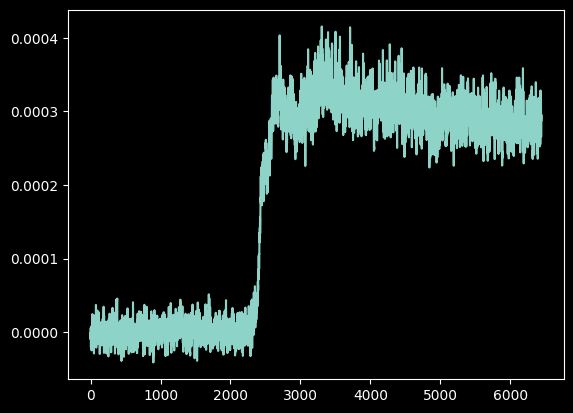

In [116]:
G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.emg.continuous.npy')).mean(axis=1)

D = np.zeros_like(G_obs)
for tp in range(G_obs.shape[0]):
    D[tp] = pcm.G_to_dist(G_obs[tp])

plt.plot(D.mean(axis=(1,2)))
